# 보험 산업군 파일럿 (미국 P&C 23개사) — 팀 통일 기준 적용

**목표**: 미국 손해보험사의 실적 발표와 어닝 서프라이즈가 주가·거래량에 미치는 효과를 DiD로 추정하는 파일럿

**팀 통일 기준 (10/2 회의)**

| 항목 | 통일 기준 | 이 노트북에서 구현한 방식 |
| --- | --- | --- |
| 산업 | IT · 보험 · 바이오 (미국) | 미국 상장 P&C·재보험 23개사 |
| 서프라이즈 강도 | **회사 기준** (not 시장) | 주가 스케일 SUE를 **회사별 평균·표준편차로 표준화**한 z (`sue_z`) |
| 비교 | 실적 발표 여부 + 서프라이즈(커짐/작아짐/예상) | 질문 B: 발표 vs 미발표 / 질문 A: 커짐·작아짐 vs 예상 |
| 서프라이즈 | continuous | 연속처치 이벤트스터디 (`sue_z` 1SD당 효과) |
| 대조군 선택 규칙 | **10거래일로 통일** | 처치 반응일 기준 **±10거래일 안에 자기 반응일이 없는 회사**만 대조군, 분석 창도 [−10, +10] |
| 파이프라인 | 통일 (코드 공유) | 파라미터는 0번 셀에, 데이터 소스는 1번 셀에만 모아둠 → WRDS로 바꿀 때 1번 셀만 교체 |

**데이터 (WRDS 승인 전 파일럿)**
- 실적: Alpha Vantage EARNINGS API (발표일, 장 전/후, 실제 EPS, 컨센서스) — 23개사 모두 한 출처
- 7개사 × 2025Q1~2026Q2(42건)는 SEC 8-K 접수 시각과 보도자료 원문 EPS로 검증한 값으로 덮어씀
- 주가·거래량: Yahoo Finance 일별 (수정주가), 벤치마크 SPY(시장), KIE(보험업종)

## 0. 설정

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import pyfixest as pf          # pip install pyfixest

# 한글 폰트 (Windows: Malgun Gothic / Mac: AppleGothic / Linux: Noto Sans CJK)
_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["Malgun Gothic", "AppleGothic", "Noto Sans CJK KR", "Noto Sans CJK JP", "NanumGothic"]:
    if _f in _fonts:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

DATA_DIR = "data/"
SAMPLE_START = "2021-01-01"     # 회계분기 말 기준 (2021Q1 ~ 2026Q2, 22분기)
WINDOW = 10                     # 이벤트 창 [-10, +10] 거래일 (팀 통일)
CLEAN_H = 10                    # 대조군: 처치 반응일 ±10거래일 안에 자기 반응일이 없어야 함 (팀 통일)
QA_MATCH_H = 10                 # 질문 A: '예상' 대조 이벤트는 처치 반응일 ±10거래일 안에 발표한 회사
Z_CUT = 0.5                     # 서프라이즈 그룹: z > +0.5 커짐 / z < -0.5 작아짐 / 나머지 예상
VOL_BASE = (-60, -21)           # 비정상 거래량 기준구간 (바이오·IT와 동일)
MARKET, SECTOR = "SPY", "KIE"
PLACEBO_SHIFT = 30              # 플라시보: 반응일을 30거래일 앞으로
REF_BIN = list(range(-10, -5))  # |AR|·거래량의 기준 구간 k=-10~-6 (CAR은 k=-1 기준)

# 회사 하위그룹 (파일럿용 분류: 사업 구성 기준, 10-K 사업부문으로 재확인 필요)
SUBGROUP = {
    "large_multiline": ["TRV", "CB", "AIG", "HIG", "CNA", "CINF"],              # 대형 다각화 (기업+개인)
    "personal_lines":  ["ALL", "MCY", "KMPR", "HCI"],                             # 개인보험(자동차·주택) 중심
    "specialty_reins": ["WRB", "MKL", "ACGL", "AXS", "KNSL", "RLI", "SIGI",      # 특수·기업보험·재보험
                        "AFG", "THG", "ORI", "PLMR", "RNR", "EG"],
}
SUB_OF = {t: g for g, ts in SUBGROUP.items() for t in ts}
TICKERS = sorted(SUB_OF)
print(len(TICKERS), "개사:", TICKERS)

23 개사: ['ACGL', 'AFG', 'AIG', 'ALL', 'AXS', 'CB', 'CINF', 'CNA', 'EG', 'HCI', 'HIG', 'KMPR', 'KNSL', 'MCY', 'MKL', 'ORI', 'PLMR', 'RLI', 'RNR', 'SIGI', 'THG', 'TRV', 'WRB']


## 1. 데이터 불러오기
WRDS 승인 후에는 이 셀만 I/B/E/S(발표일·시각·실제 EPS·컨센서스) + CRSP(주가·거래량)로 바꾸면 됨.
아래 셀부터는 `earn`(실적 테이블)과 `px`(일별 주가 테이블)의 컬럼 이름만 맞으면 그대로 돌아감.

In [2]:
# (1) 실적: Alpha Vantage EARNINGS (14개사 + 추가 9개사)
earn = pd.concat([pd.read_csv(DATA_DIR + "alphavantage_pc14_2021Q1_2026Q2.csv"),
                  pd.read_csv(DATA_DIR + "av_new9.csv")], ignore_index=True)
earn["fiscal_end"] = pd.to_datetime(earn["fiscal_end"])
earn = earn[(earn.fiscal_end >= SAMPLE_START) & earn.ticker.isin(TICKERS)].copy()
earn["quarter"] = earn.fiscal_end.dt.year.astype(str) + "Q" + earn.fiscal_end.dt.quarter.astype(str)
earn = earn.rename(columns={"reported_date": "announce_date", "reported_eps_av": "eps_actual",
                            "estimated_eps_av": "eps_consensus"})
earn["timing"] = earn.report_time.map({"pre-market": "BMO", "post-market": "AMC"})
earn["source"] = "AlphaVantage"

# (2) 검증값 덮어쓰기: 7개사 × 2025Q1~2026Q2 (SEC 8-K 접수 시각, 보도자료 원문 조정 EPS)
ver = pd.read_csv(DATA_DIR + "pc_panel_2025Q1_2026Q2.csv")
ver = ver[["quarter", "ticker", "announce_date", "timing", "reported_eps"]].rename(
    columns={"announce_date": "v_date", "timing": "v_timing", "reported_eps": "v_eps"})
earn = earn.merge(ver, on=["quarter", "ticker"], how="left")
hit = earn.v_date.notna()
n_eps_fix = int((hit & (earn.v_eps - earn.eps_actual).abs().gt(0.005)).sum())
earn.loc[hit, "announce_date"] = earn.loc[hit, "v_date"]
earn.loc[hit, "timing"] = earn.loc[hit, "v_timing"]
earn.loc[hit, "eps_actual"] = earn.loc[hit, "v_eps"]
earn.loc[hit, "source"] = "AV + SEC/보도자료 검증"
earn = earn.drop(columns=["v_date", "v_timing", "v_eps", "report_time"])
print(f"실적 {len(earn)}건 ({earn.ticker.nunique()}개사 × {earn.quarter.nunique()}분기), "
      f"검증값으로 덮어쓴 행 {hit.sum()}건 (그중 실제 EPS가 바뀐 행 {n_eps_fix}건: AV에 GAAP EPS가 들어 있던 분기)")

# (3) 주가·거래량: Yahoo Finance 일별 (close = 분할 조정, adjclose = 분할+배당 조정)
px = pd.read_csv(DATA_DIR + "ins_prices_2020_2026.csv", parse_dates=["date"])
CAL = pd.DatetimeIndex(sorted(px.date.unique()))
ADJ = px.pivot(index="date", columns="ticker", values="adjclose").reindex(CAL)
CLOSE = px.pivot(index="date", columns="ticker", values="close").reindex(CAL)
VOL = px.pivot(index="date", columns="ticker", values="volume").reindex(CAL)
RET = ADJ.pct_change() * 100                                   # 일별 수익률 (%)
AR_MKT = RET[TICKERS].sub(RET[MARKET], axis=0)                 # 시장(SPY) 조정 초과수익률
AR_SEC = RET[TICKERS].sub(RET[SECTOR], axis=0)                 # 업종(KIE) 조정 (강건성)
LOGV = np.log(VOL[TICKERS].replace(0, np.nan))
print(f"주가: {CAL[0].date()} ~ {CAL[-1].date()}, {len(CAL)}거래일, 결측 {int(ADJ[TICKERS].isna().sum().sum())}개")

실적 506건 (23개사 × 22분기), 검증값으로 덮어쓴 행 42건 (그중 실제 EPS가 바뀐 행 5건: AV에 GAAP EPS가 들어 있던 분기)
주가: 2020-06-01 ~ 2026-09-30, 1592거래일, 결측 0개


## 2. 이벤트 테이블
- **반응일(t0)**: 장 전(BMO) 발표 → 발표 당일, 장 후(AMC) 발표 → 다음 거래일 (발표일이 휴장일이면 다음 거래일)
- **SUE (주가 스케일)** = (실제 EPS − 컨센서스) ÷ t0 기준 2거래일 전 종가 × 100 (%)
- **회사 기준 서프라이즈 `sue_z`** = (SUE − 그 회사 22분기 평균) ÷ 그 회사 표준편차 → "그 회사치고 얼마나 놀라웠나"
- **그룹**: `sue_z` > +0.5 → 커짐 / < −0.5 → 작아짐 / 그 사이 → 예상(평소 수준)
- **EPS 의심 플래그**: |SUE| > 1.5% 이면서 |서프라이즈%| > 75% → AV에 GAAP EPS가 섞였을 가능성 (강건성에서 제외해 봄)

In [3]:
def reaction_index(date, timing):
    d = pd.Timestamp(date)
    i = CAL.searchsorted(d)                      # d 이상인 첫 거래일
    if timing == "AMC" and i < len(CAL) and CAL[i] == d:
        i += 1
    return int(i)

ev = earn.copy()
ev["t0i"] = [reaction_index(d, t) for d, t in zip(ev.announce_date, ev.timing)]
ev["t0_date"] = CAL[ev.t0i.clip(upper=len(CAL) - 1)]
ev["subgroup"] = ev.ticker.map(SUB_OF)
ev["p_m2"] = [CLOSE.at[CAL[i - 2], t] for i, t in zip(ev.t0i, ev.ticker)]
ev["surprise_pct"] = (ev.eps_actual - ev.eps_consensus) / ev.eps_consensus.abs() * 100
ev["sue"] = (ev.eps_actual - ev.eps_consensus) / ev.p_m2 * 100

g = ev.groupby("ticker")["sue"]
ev["sue_z"] = (ev.sue - g.transform("mean")) / g.transform("std")          # 메인: 회사 기준
ev["sue_scale"] = ev.sue / g.transform("std")                                # 강건성: 스케일만 (바이오 메인)
ev["sue_pool"] = (ev.sue - ev.sue.mean()) / ev.sue.std()                     # 비교용: 시장(전체) 기준
ev = ev.sort_values(["ticker", "t0i"]).reset_index(drop=True)
def _past_z(s, min_n=6):                                                     # 강건성: 과거 분기만 사용 (look-ahead 없음)
    out = []
    for i in range(len(s)):
        h = s.iloc[:i]
        out.append((s.iloc[i] - h.mean()) / h.std() if len(h) >= min_n else np.nan)
    return pd.Series(out, index=s.index)
ev["sue_z_past"] = ev.groupby("ticker")["sue"].transform(_past_z)

ev["group"] = np.select([ev.sue_z > Z_CUT, ev.sue_z < -Z_CUT], ["커짐", "작아짐"], "예상")
ev["eps_flag"] = (ev.sue.abs() > 1.5) & (ev.surprise_pct.abs() > 75)
ev["eid"] = ev.ticker + "_" + ev.quarter

# 윈도우·기준구간이 가격 데이터 안에 들어오는지
ev["ok_window"] = (ev.t0i + VOL_BASE[0] >= 1) & (ev.t0i + WINDOW < len(CAL))
print(f"이벤트 {len(ev)}건, 창 확보 {ev.ok_window.sum()}건")
print("발표 시각:", ev.timing.value_counts().to_dict())
print("서프라이즈 그룹:", ev.group.value_counts().to_dict())
print("EPS 의심 플래그:", int(ev.eps_flag.sum()), "건 →", ev.loc[ev.eps_flag, "eid"].tolist())
print(f"예상 상회(실제>컨센서스) 비율: {(ev.eps_actual > ev.eps_consensus).mean():.1%}")
ev[["eid", "subgroup", "announce_date", "timing", "t0_date", "eps_actual", "eps_consensus",
    "surprise_pct", "sue", "sue_z", "group", "eps_flag", "source"]].head(8)

이벤트 506건, 창 확보 506건
발표 시각: {'AMC': 423, 'BMO': 83}
서프라이즈 그룹: {'예상': 245, '작아짐': 132, '커짐': 129}
EPS 의심 플래그: 30 건 → ['AIG_2021Q1', 'AIG_2021Q2', 'AIG_2021Q3', 'AIG_2021Q4', 'AIG_2022Q1', 'AIG_2022Q2', 'AIG_2022Q3', 'AIG_2023Q1', 'AIG_2023Q3', 'AXS_2023Q4', 'CINF_2024Q3', 'HCI_2023Q1', 'HCI_2023Q3', 'HCI_2023Q4', 'HCI_2024Q4', 'KMPR_2021Q2', 'KMPR_2021Q4', 'KMPR_2025Q3', 'MCY_2022Q1', 'MCY_2022Q3', 'MCY_2022Q4', 'MCY_2023Q3', 'MCY_2023Q4', 'MCY_2024Q3', 'MCY_2024Q4', 'MCY_2025Q2', 'MCY_2025Q3', 'MCY_2026Q2', 'MKL_2021Q1', 'SIGI_2024Q2']
예상 상회(실제>컨센서스) 비율: 76.9%


,eid,subgroup,announce_date,timing,t0_date,eps_actual,eps_consensus,surprise_pct,sue,sue_z,group,eps_flag,source
0,ACGL_2021Q1,specialty_reins,2021-04-27,AMC,2021-04-28,0.59,0.45,31.111111,0.348692,-0.369566,예상,False,AlphaVantage
1,ACGL_2021Q2,specialty_reins,2021-07-28,AMC,2021-07-29,1.00,0.84,19.047619,0.415261,-0.137769,예상,False,AlphaVantage
2,ACGL_2021Q3,specialty_reins,2021-10-27,AMC,2021-10-28,0.74,0.35,111.428571,0.903824,1.563454,커짐,False,AlphaVantage
3,ACGL_2021Q4,specialty_reins,2022-02-09,AMC,2022-02-10,1.27,0.99,28.282828,0.580913,0.439047,예상,False,AlphaVantage
4,ACGL_2022Q1,specialty_reins,2022-04-27,AMC,2022-04-28,1.10,1.07,2.803738,0.064502,-1.359143,작아짐,False,AlphaVantage
5,ACGL_2022Q2,specialty_reins,2022-07-27,AMC,2022-07-28,1.34,1.07,25.233645,0.610307,0.541402,커짐,False,AlphaVantage
6,ACGL_2022Q3,specialty_reins,2022-10-26,AMC,2022-10-27,0.28,0.18,55.555556,0.203169,-0.876291,작아짐,False,AlphaVantage
7,ACGL_2022Q4,specialty_reins,2023-02-13,AMC,2023-02-14,2.14,1.34,59.701493,1.245718,2.753960,커짐,False,AlphaVantage


### 2-1. 왜 '회사 기준'이어야 하는가: 회사별 SUE 분포

In [4]:
firm = ev.groupby("ticker").agg(sub=("subgroup", "first"), n=("sue", "size"), sue_mean=("sue", "mean"),
                                sue_sd=("sue", "std"), beat_rate=("surprise_pct", lambda s: (s > 0).mean()),
                                n_big=("group", lambda s: (s == "커짐").sum()),
                                n_small=("group", lambda s: (s == "작아짐").sum())).round(3)
pool_top = ev.nlargest(int(len(ev) * 0.2), "sue_pool").ticker.value_counts()
firm["pool_top20_n"] = pool_top.reindex(firm.index).fillna(0).astype(int)
print("시장(전체) 기준 상위 20% 이벤트를 가장 많이 차지한 회사:", pool_top.head(4).to_dict())
firm.sort_values("sue_mean", ascending=False)

시장(전체) 기준 상위 20% 이벤트를 가장 많이 차지한 회사: {'MCY': 12, 'HCI': 11, 'RNR': 10, 'ALL': 10}


,sub,n,sue_mean,sue_sd,beat_rate,n_big,n_small,pool_top20_n
ticker,,,,,,,,
AIG,large_multiline,22,1.419,2.861,0.773,6,5,8
MCY,personal_lines,22,0.951,1.866,0.682,8,7,12
HCI,personal_lines,22,0.805,0.973,0.818,6,5,11
AXS,specialty_reins,22,0.698,1.217,0.864,1,3,6
ALL,personal_lines,22,0.621,0.797,0.727,8,7,10
RNR,specialty_reins,22,0.619,0.905,0.773,4,5,10
ACGL,specialty_reins,22,0.455,0.287,1.000,4,5,3
TRV,large_multiline,22,0.425,0.588,0.818,7,4,9
EG,specialty_reins,22,0.396,0.999,0.773,3,5,9


### 2-2. 발표 시점 분산과 '±10거래일' 대조군 확보 가능성

±10거래일 규칙: 이벤트당 대조군 평균 2.0개, 중앙값 1, 대조군 0개 이벤트 210건 (42%)
± 5거래일 규칙: 이벤트당 대조군 평균 7.9개, 중앙값 7, 대조군 0개 이벤트 0건 (0%)
± 3거래일 규칙: 이벤트당 대조군 평균 13.4개, 중앙값 13, 대조군 0개 이벤트 0건 (0%)


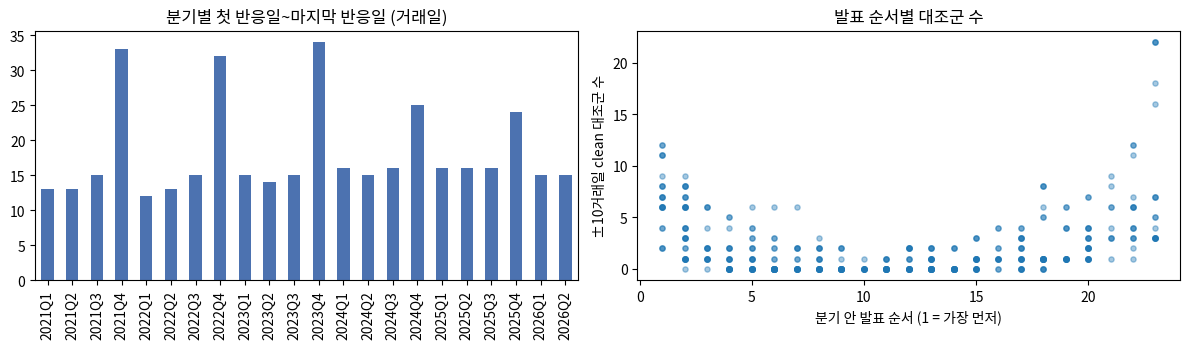

ticker,HIG,EG,THG,MKL,CINF,AXS,CNA,ACGL,SIGI,ALL,CB,RNR,AFG,KMPR,MCY,ORI,KNSL,AIG,PLMR,RLI,WRB,TRV,HCI
평균 대조군 수,0.4,0.5,0.5,0.6,0.8,0.9,0.9,1.0,1.1,1.2,1.4,1.4,1.5,1.7,1.9,2.0,2.0,2.4,2.7,2.9,3.3,7.4,7.8


In [5]:
OWN_T0 = {t: np.array(sorted(g.t0i)) for t, g in ev.groupby("ticker")}

def clean_controls(ticker, t0i, h=CLEAN_H, pool=None):
    pool = TICKERS if pool is None else pool
    return [j for j in pool if j != ticker and not (np.abs(OWN_T0[j] - t0i) <= h).any()]

for h in [10, 5, 3]:
    n = ev.apply(lambda r: len(clean_controls(r.ticker, r.t0i, h)), axis=1)
    print(f"±{h:>2}거래일 규칙: 이벤트당 대조군 평균 {n.mean():.1f}개, 중앙값 {n.median():.0f}, "
          f"대조군 0개 이벤트 {int((n == 0).sum())}건 ({(n == 0).mean():.0%})")
ev["n_clean"] = ev.apply(lambda r: len(clean_controls(r.ticker, r.t0i)), axis=1)

# 시즌 안에서의 발표 순서와 대조군 수
ev["season_rank"] = ev.groupby("quarter").t0i.rank(method="min")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ev.groupby("quarter").t0i.agg(lambda s: s.max() - s.min()).plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("분기별 첫 반응일~마지막 반응일 (거래일)"); ax[0].set_xlabel("")
ax[1].scatter(ev.season_rank, ev.n_clean, alpha=0.4, s=14)
ax[1].set_xlabel("분기 안 발표 순서 (1 = 가장 먼저)"); ax[1].set_ylabel("±10거래일 clean 대조군 수")
ax[1].set_title("발표 순서별 대조군 수")
plt.tight_layout(); plt.show()
ev.groupby("ticker").n_clean.mean().sort_values().round(1).to_frame("평균 대조군 수").T

### 2-3. 반응일이 맞는지 점검 (IT 파트 ⑥과 같은 방식)
반응일이 맞다면 t0에서 주가가 가장 크게 움직여야 함. 전날·다음날이 t0보다 2배 이상 크고 3%p 이상이면 날짜·시각 오류 의심.

In [6]:
def _absar(t, i):
    return abs(AR_MKT[t].values[i]) if 0 <= i < len(CAL) else np.nan
chk = ev[["eid", "ticker", "timing", "t0_date", "source"]].copy()
for k in (-1, 0, 1):
    chk[f"absar_{k}"] = [_absar(t, i + k) for t, i in zip(ev.ticker, ev.t0i)]
chk["max_day"] = chk[["absar_-1", "absar_0", "absar_1"]].idxmax(axis=1).str.replace("absar_", "")
nb = chk[["absar_-1", "absar_1"]].max(axis=1)
chk["suspect_date"] = (nb > 2 * chk.absar_0) & (nb > 3)
ev["suspect_date"] = chk.suspect_date.values
print("세 날 중 t0가 가장 크게 움직인 비율:", f"{(chk.max_day == '0').mean():.0%}")
print("날짜 의심 이벤트:", int(chk.suspect_date.sum()), "건")
chk[chk.suspect_date].round(2)

세 날 중 t0가 가장 크게 움직인 비율: 63%
날짜 의심 이벤트: 32 건


,eid,ticker,timing,t0_date,source,absar_-1,absar_0,absar_1,max_day,suspect_date
19,ACGL_2025Q4,ACGL,AMC,2026-02-10,AlphaVantage,5.33,2.13,0.80,-1,True
21,ACGL_2026Q2,ACGL,AMC,2026-07-29,AlphaVantage,2.26,0.27,4.94,1,True
40,AFG_2025Q3,AFG,AMC,2025-11-05,AlphaVantage,2.04,2.45,5.69,1,True
47,AIG_2021Q4,AIG,BMO,2022-02-16,AlphaVantage,0.74,0.18,3.86,1,True
48,AIG_2022Q1,AIG,BMO,2022-05-03,AlphaVantage,0.34,0.34,4.36,1,True
52,AIG_2023Q1,AIG,BMO,2023-05-04,AlphaVantage,0.43,2.15,5.99,1,True
92,AXS_2022Q1,AXS,AMC,2022-04-28,AlphaVantage,5.45,1.29,2.39,-1,True
109,AXS_2026Q2,AXS,AMC,2026-07-28,AlphaVantage,0.45,1.66,9.62,1,True
198,HCI_2021Q1,HCI,AMC,2021-05-07,AlphaVantage,0.71,1.01,3.49,1,True
215,HCI_2025Q2,HCI,AMC,2025-08-08,AlphaVantage,1.33,1.00,10.18,1,True


## 3. 공통 함수
- `build_panel`: 스택(이벤트 묶음)마다 처치 1개 + 대조군을 [−10, +10] 창으로 펼침
- 결과변수: `abs_ar`(주가 흔들림, |AR|), `ar`(초과수익률), `car`(t=−1 기준 누적 초과수익률), `abvol`(비정상 log 거래량)
- 추정: $Y_{j,s,k} = \alpha_{j,s} + \lambda_{s,k} + \sum_{k\neq-1}\beta_k\,\mathbf{1}[t=k]\cdot Treat_{j,s} + \varepsilon$ (스택×회사, 스택×시점 고정효과), SE는 회사 단위 클러스터
- 기준 시점: CAR은 k=−1(누적이 0인 날), |AR|·거래량은 k=−10~−6 평균 (하루짜리 기준은 잡음이 커서 구간으로 둠)
- 회사가 23개라 클러스터가 적음 → CI는 참고용

In [7]:
KS = np.arange(-WINDOW, WINDOW + 1)

def build_panel(rows, ar=AR_MKT, extra_cols=()):
    """rows: dict(sid, ticker, align_i, treat, 그 외 컬럼) 리스트 → 스택 패널"""
    out = []
    for r in rows:
        t, a = r["ticker"], r["align_i"]
        idx = a + KS
        if idx.min() + (VOL_BASE[0] + WINDOW) < 0 or idx.max() >= len(CAL):
            continue
        arv = ar[t].values[idx]
        base = LOGV[t].values[a + VOL_BASE[0]: a + VOL_BASE[1] + 1]
        car = np.cumsum(np.nan_to_num(arv))
        car = car - car[WINDOW - 1]                      # t=-1에서 0
        d = pd.DataFrame({"k": KS, "ar": arv, "abs_ar": np.abs(arv), "car": car,
                          "abvol": LOGV[t].values[idx] - np.nanmean(base)})
        for c, v in r.items():
            d[c] = v
        out.append(d)
    P = pd.concat(out, ignore_index=True)
    P["unit"] = P.sid.astype(str) + "|" + P.ticker
    P["sk"] = P.sid.astype(str) + "|" + P.k.astype(str)
    return P

def _refs(ref):
    return [ref] if np.isscalar(ref) else list(ref)

def _finish(m, prefix, refs):
    t = m.tidy().reset_index()
    t["k"] = t["Coefficient"].str[1:].astype(int) - WINDOW
    t = t.rename(columns={"Estimate": "b", "Std. Error": "se", "2.5%": "lo", "97.5%": "hi", "Pr(>|t|)": "p"})
    z = pd.DataFrame({"k": refs, "b": 0.0, "se": 0.0, "lo": 0.0, "hi": 0.0, "p": np.nan})
    return pd.concat([t, z]).sort_values("k")[["k", "b", "se", "lo", "hi", "p"]].reset_index(drop=True)

def es_did(P, y, treat="treat", ref=-1):
    """스택 이벤트스터디 DiD → k별 계수표. ref: 기준 시점(정수) 또는 기준 구간(리스트)"""
    P = P.copy(); refs = _refs(ref)
    for k in KS:
        if k not in refs:
            P[f"d{k + WINDOW}"] = ((P.k == k) & (P[treat] == 1)).astype(float)
    xs = " + ".join(f"d{k + WINDOW}" for k in KS if k not in refs)
    m = pf.feols(f"{y} ~ {xs} | unit + sk", data=P, vcov={"CRV1": "ticker"})
    return _finish(m, "d", refs)

def es_cont(P, y, x="sue_z", ref=-1, fe="eid + sgk"):
    """연속처치 이벤트스터디: 이벤트당 1개 회사 → 이벤트 FE + 하위그룹×시점 FE"""
    P = P.copy(); refs = _refs(ref)
    P["sgk"] = P.subgroup + "|" + P.k.astype(str)
    for k in KS:
        if k not in refs:
            P[f"x{k + WINDOW}"] = np.where(P.k == k, P[x], 0.0)
    xs = " + ".join(f"x{k + WINDOW}" for k in KS if k not in refs)
    m = pf.feols(f"{y} ~ {xs} | {fe}", data=P, vcov={"CRV1": "ticker"})
    return _finish(m, "x", refs)

def plot_es(tabs, title, ylab, ax=None):
    ax = ax or plt.subplots(figsize=(7, 3.8))[1]
    for i, (lab, t) in enumerate(tabs.items()):
        off = (i - (len(tabs) - 1) / 2) * 0.18
        ax.errorbar(t.k + off, t.b, yerr=[t.b - t.lo, t.hi - t.b], fmt="o-", ms=3.5, lw=1, capsize=2, label=lab)
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(-0.5, color="gray", lw=0.8, ls="--")
    ax.set_title(title); ax.set_xlabel("반응일 기준 거래일 (k)"); ax.set_ylabel(ylab)
    if len(tabs) > 1:
        ax.legend(fontsize=8)
    return ax

def pick(t, ks=(0, 1, 5, 10)):
    return {f"k={k}": f"{t.set_index('k').at[k, 'b']:.2f} [{t.set_index('k').at[k, 'lo']:.2f}, {t.set_index('k').at[k, 'hi']:.2f}]" for k in ks}

def pre_test(t, lo=-WINDOW, hi=-2):
    s = t[(t.k >= lo) & (t.k <= hi)]
    return f"사전기간 k={lo}~{hi}: CI가 0을 벗어난 계수 {int(((s.lo > 0) | (s.hi < 0)).sum())}/{len(s)}개, 평균 {s.b.mean():.2f}"

EVU = ev[ev.ok_window].copy()       # 분석 사용 이벤트

## 4. 질문 B (DiD 메인) — 실적 발표 자체의 효과
- 처치: 실적을 발표한 회사 1곳 / 대조: 처치 반응일 **±10거래일 안에 자기 반응일이 없는** 보험사 (팀 통일 규칙)
- 대조군이 1개 이상인 이벤트만 사용

질문 B 사용 이벤트 296/506건 (대조군 0개라 빠진 이벤트 210건), 이벤트당 평균 대조군 3.4개
사용된 이벤트의 발표 순서 분포(분기 안 순위): {'mean': 12.0, '50%': 13.0}  / 전체: {'mean': 11.1, '50%': 11.0}


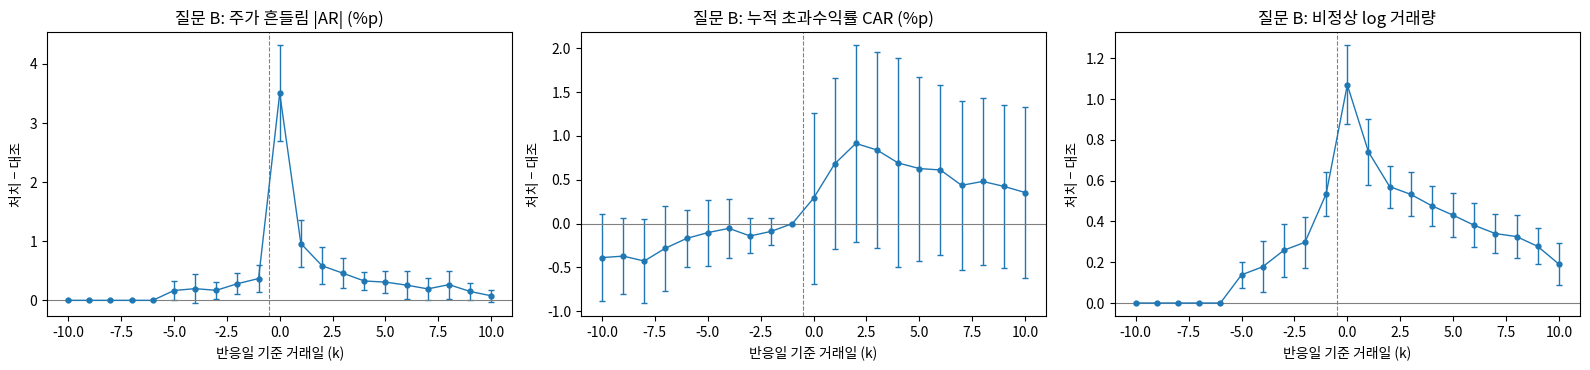

|AR|   {'k=-1': '0.37 [0.15, 0.59]', 'k=0': '3.50 [2.69, 4.32]', 'k=1': '0.96 [0.56, 1.36]', 'k=2': '0.59 [0.27, 0.90]', 'k=5': '0.31 [0.13, 0.49]', 'k=10': '0.08 [-0.03, 0.18]'} | 사전기간 k=-5~-2: CI가 0을 벗어난 계수 3/4개, 평균 0.20
CAR    {'k=-1': '0.00 [0.00, 0.00]', 'k=0': '0.29 [-0.69, 1.26]', 'k=1': '0.68 [-0.29, 1.66]', 'k=2': '0.91 [-0.21, 2.04]', 'k=5': '0.63 [-0.42, 1.68]', 'k=10': '0.35 [-0.62, 1.33]'} | 사전기간 k=-10~-2: CI가 0을 벗어난 계수 0/9개, 평균 -0.23
abvol  {'k=-1': '0.54 [0.43, 0.64]', 'k=0': '1.07 [0.88, 1.26]', 'k=1': '0.74 [0.58, 0.90]', 'k=2': '0.57 [0.47, 0.67]', 'k=5': '0.43 [0.32, 0.54]', 'k=10': '0.19 [0.09, 0.29]'} | 사전기간 k=-5~-2: CI가 0을 벗어난 계수 4/4개, 평균 0.22


In [8]:
def qb_rows(evs, h=CLEAN_H, pool_fn=None, shift=0):
    rows = []
    for _, r in evs.iterrows():
        pool = pool_fn(r) if pool_fn else None
        ctrl = clean_controls(r.ticker, r.t0i, h, pool)
        if not ctrl:
            continue
        a = r.t0i - shift
        rows.append(dict(sid=r.eid, ticker=r.ticker, align_i=a, treat=1, subgroup=r.subgroup))
        rows += [dict(sid=r.eid, ticker=j, align_i=a, treat=0, subgroup=SUB_OF[j]) for j in ctrl]
    return rows

PB = build_panel(qb_rows(EVU))
nb_ev = PB[PB.treat == 1].sid.nunique()
print(f"질문 B 사용 이벤트 {nb_ev}/{len(EVU)}건 (대조군 0개라 빠진 이벤트 {len(EVU) - nb_ev}건), "
      f"이벤트당 평균 대조군 {PB[PB.treat == 0].groupby('sid').ticker.nunique().mean():.1f}개")
kept = EVU[EVU.eid.isin(PB.sid.unique())]
print("사용된 이벤트의 발표 순서 분포(분기 안 순위):", kept.season_rank.describe()[["mean", "50%"]].round(1).to_dict(),
      " / 전체:", EVU.season_rank.describe()[["mean", "50%"]].round(1).to_dict())

B_abs = es_did(PB, "abs_ar", ref=REF_BIN); B_ar = es_did(PB, "car"); B_vol = es_did(PB, "abvol", ref=REF_BIN)
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
plot_es({"|AR|": B_abs}, "질문 B: 주가 흔들림 |AR| (%p)", "처치 − 대조", ax[0])
plot_es({"CAR": B_ar}, "질문 B: 누적 초과수익률 CAR (%p)", "처치 − 대조", ax[1])
plot_es({"log 거래량": B_vol}, "질문 B: 비정상 log 거래량", "처치 − 대조", ax[2])
plt.tight_layout(); plt.show()
for nm, t, pre in [("|AR|", B_abs, (-5, -2)), ("CAR", B_ar, (-10, -2)), ("abvol", B_vol, (-5, -2))]:
    print(f"{nm:6s}", pick(t, (-1, 0, 1, 2, 5, 10)), "|", pre_test(t, *pre))

## 5. 질문 A (DiD 보조) — 서프라이즈가 '평소보다' 컸을 때 vs 평소 수준일 때
- 처치: `커짐`(sue_z > +0.5) 또는 `작아짐`(sue_z < −0.5) 이벤트 1건
- 대조: 처치 반응일 **±10거래일 안에** 반응일이 있는 **다른 회사의 `예상` 이벤트** (|sue_z| ≤ 0.5)
- 둘 다 발표했으므로 '발표 효과'는 빠지고 '서프라이즈 크기' 차이만 남음. 각자 자기 반응일(t0)에 정렬
- 결과변수: 누적 초과수익률 CAR (t=−1에서 0)

커짐: 처치 이벤트 128건, 스택당 '예상' 대조 평균 9.5개
작아짐: 처치 이벤트 132건, 스택당 '예상' 대조 평균 10.3개


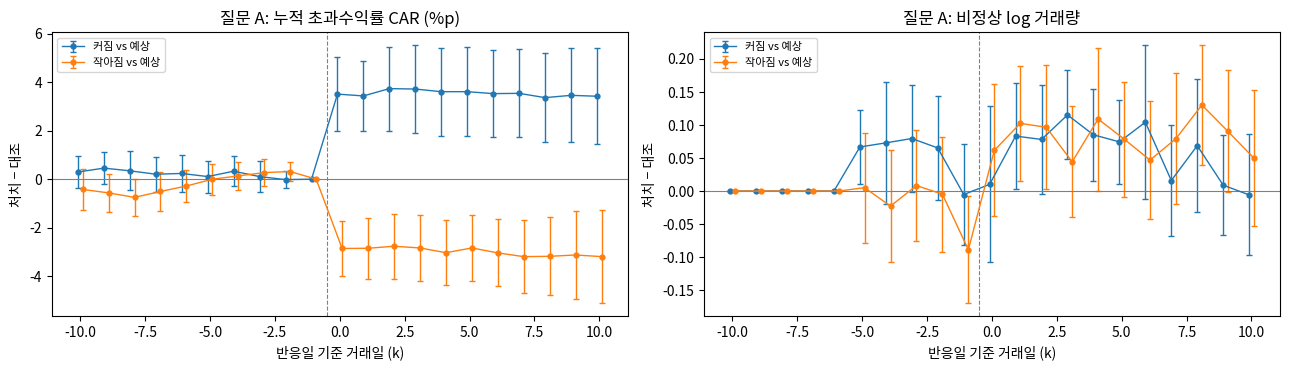

커짐 CAR    {'k=0': '3.52 [2.00, 5.03]', 'k=1': '3.44 [1.98, 4.90]', 'k=5': '3.62 [1.78, 5.46]', 'k=10': '3.43 [1.45, 5.41]'} | 사전기간 k=-10~-2: CI가 0을 벗어난 계수 0/9개, 평균 0.23
작아짐 CAR   {'k=0': '-2.86 [-3.99, -1.73]', 'k=1': '-2.85 [-4.11, -1.60]', 'k=5': '-2.84 [-4.19, -1.49]', 'k=10': '-3.20 [-5.12, -1.28]'} | 사전기간 k=-10~-2: CI가 0을 벗어난 계수 0/9개, 평균 -0.20
커짐 vol    {'k=0': '0.01 [-0.11, 0.13]', 'k=1': '0.08 [0.00, 0.16]', 'k=5': '0.07 [0.01, 0.14]', 'k=10': '-0.01 [-0.10, 0.09]'} | 사전기간 k=-5~-2: CI가 0을 벗어난 계수 1/4개, 평균 0.07
작아짐 vol   {'k=0': '0.06 [-0.04, 0.16]', 'k=1': '0.10 [0.02, 0.19]', 'k=5': '0.08 [-0.01, 0.17]', 'k=10': '0.05 [-0.05, 0.15]'} | 사전기간 k=-5~-2: CI가 0을 벗어난 계수 0/4개, 평균 -0.00


In [9]:
def qa_rows(evs, treat_group, h=QA_MATCH_H, z="sue_z", cut=Z_CUT):
    neutral = evs[evs[z].abs() <= cut]
    tg = evs[evs[z] > cut] if treat_group == "커짐" else evs[evs[z] < -cut]
    rows = []
    for _, r in tg.iterrows():
        c = neutral[(neutral.ticker != r.ticker) & ((neutral.t0i - r.t0i).abs() <= h)]
        if c.empty:
            continue
        rows.append(dict(sid=r.eid, ticker=r.ticker, align_i=r.t0i, treat=1, subgroup=r.subgroup))
        rows += [dict(sid=r.eid, ticker=c2.ticker, align_i=c2.t0i, treat=0, subgroup=c2.subgroup)
                 for _, c2 in c.iterrows()]
    return rows

PA_up = build_panel(qa_rows(EVU, "커짐")); PA_dn = build_panel(qa_rows(EVU, "작아짐"))
for nm, P in [("커짐", PA_up), ("작아짐", PA_dn)]:
    print(f"{nm}: 처치 이벤트 {P[P.treat == 1].sid.nunique()}건, 스택당 '예상' 대조 평균 "
          f"{P[P.treat == 0].groupby('sid').unit.nunique().mean():.1f}개")
A_up = es_did(PA_up, "car"); A_dn = es_did(PA_dn, "car")
A_up_v = es_did(PA_up, "abvol", ref=REF_BIN); A_dn_v = es_did(PA_dn, "abvol", ref=REF_BIN)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
plot_es({"커짐 vs 예상": A_up, "작아짐 vs 예상": A_dn}, "질문 A: 누적 초과수익률 CAR (%p)", "처치 − 대조", ax[0])
plot_es({"커짐 vs 예상": A_up_v, "작아짐 vs 예상": A_dn_v}, "질문 A: 비정상 log 거래량", "처치 − 대조", ax[1])
plt.tight_layout(); plt.show()
for nm, t, pre in [("커짐 CAR", A_up, (-10, -2)), ("작아짐 CAR", A_dn, (-10, -2)),
                   ("커짐 vol", A_up_v, (-5, -2)), ("작아짐 vol", A_dn_v, (-5, -2))]:
    print(f"{nm:9s}", pick(t), "|", pre_test(t, *pre))

## 6. 연속처치 — 회사 기준 서프라이즈(sue_z) 1SD당 효과
- 모든 이벤트 사용, 이벤트 FE + 하위그룹×시점 FE
- CAR 계수 = "그 회사 평소보다 서프라이즈가 1SD 클 때 누적 초과수익률이 몇 %p 더 오르나"

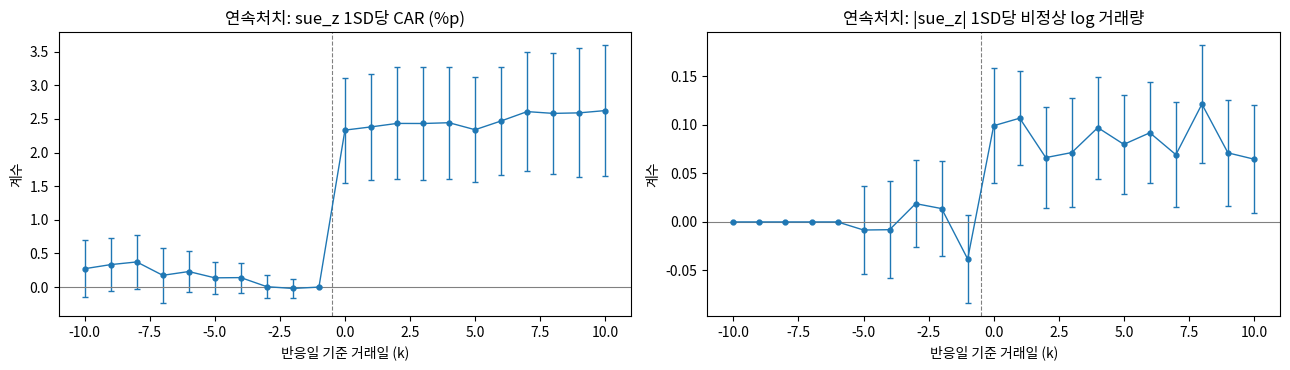

사용 이벤트 506건
CAR   {'k=0': '2.33 [1.55, 3.11]', 'k=1': '2.38 [1.59, 3.18]', 'k=5': '2.34 [1.56, 3.12]', 'k=10': '2.62 [1.65, 3.60]'} | 사전기간 k=-10~-2: CI가 0을 벗어난 계수 0/9개, 평균 0.18
거래량 {'k=0': '0.10 [0.04, 0.16]', 'k=1': '0.11 [0.06, 0.16]', 'k=5': '0.08 [0.03, 0.13]', 'k=10': '0.06 [0.01, 0.12]'} | 사전기간 k=-5~-2: CI가 0을 벗어난 계수 0/4개, 평균 0.00

CAR[0,+1] 비대칭 기울기 (1SD당 %p):
             Estimate   2.5%  97.5%  Pr(>|t|)
Coefficient                                  
Intercept       0.539 -0.449  1.526     0.270
pos             1.845  0.563  3.127     0.007
neg             3.003  1.613  4.393     0.000


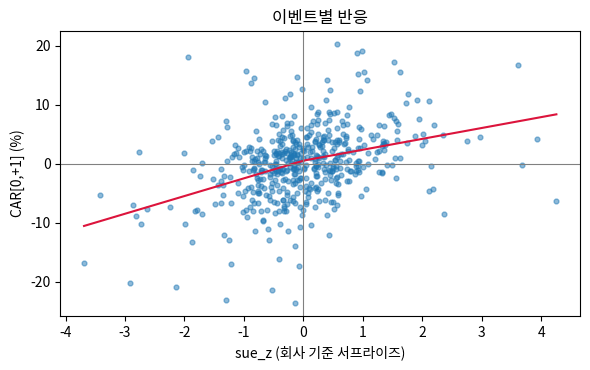

In [10]:
def cont_rows(evs, shift=0):
    return [dict(sid=r.eid, eid=r.eid, ticker=r.ticker, align_i=r.t0i - shift, treat=1, subgroup=r.subgroup,
                 sue_z=r.sue_z, sue_scale=r.sue_scale, sue_pool=r.sue_pool, sue_z_past=r.sue_z_past,
                 abs_z=abs(r.sue_z), eps_flag=r.eps_flag, quarter=r.quarter)
            for _, r in evs.iterrows()]

PC = build_panel(cont_rows(EVU))
C_car = es_cont(PC, "car", "sue_z"); C_vol = es_cont(PC, "abvol", "abs_z", ref=REF_BIN)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
plot_es({"CAR ~ sue_z": C_car}, "연속처치: sue_z 1SD당 CAR (%p)", "계수", ax[0])
plot_es({"거래량 ~ |sue_z|": C_vol}, "연속처치: |sue_z| 1SD당 비정상 log 거래량", "계수", ax[1])
plt.tight_layout(); plt.show()
print(f"사용 이벤트 {PC.eid.nunique()}건")
print("CAR  ", pick(C_car), "|", pre_test(C_car))
print("거래량", pick(C_vol), "|", pre_test(C_vol, -5, -2))

# 이벤트별 산점도 + 비대칭(평소보다 좋음 vs 나쁨) 기울기
cs = PC[PC.k == 1][["eid", "ticker", "car", "sue_z"]].rename(columns={"car": "car01"})
cs["pos"] = cs.sue_z.clip(lower=0); cs["neg"] = cs.sue_z.clip(upper=0)
m_asym = pf.feols("car01 ~ pos + neg", data=cs, vcov={"CRV1": "ticker"})
print("\nCAR[0,+1] 비대칭 기울기 (1SD당 %p):")
print(m_asym.tidy()[["Estimate", "2.5%", "97.5%", "Pr(>|t|)"]].round(3))
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.scatter(cs.sue_z, cs.car01, s=12, alpha=0.5)
xx = np.linspace(cs.sue_z.min(), cs.sue_z.max(), 50)
b = m_asym.coef()
ax.plot(xx, b["Intercept"] + b["pos"] * xx.clip(0) + b["neg"] * xx.clip(max=0), color="crimson")
ax.axhline(0, color="gray", lw=.8); ax.axvline(0, color="gray", lw=.8)
ax.set_xlabel("sue_z (회사 기준 서프라이즈)"); ax.set_ylabel("CAR[0,+1] (%)"); ax.set_title("이벤트별 반응")
plt.tight_layout(); plt.show()

## 7. 강건성

In [11]:
rob = []
def add(name, t, n, ks=(0, 1, 5)):
    d = {"스펙": name, "n": n}; d.update(pick(t, ks)); rob.append(d)

# 7-1. 연속처치: 서프라이즈 정의 비교
add("연속 | sue_z (회사 기준, 메인)", C_car, PC.eid.nunique())
add("연속 | sue_scale (스케일만, 바이오 메인)", es_cont(PC, "car", "sue_scale"), PC.eid.nunique())
P_past = PC[PC.sue_z_past.notna()]
add("연속 | sue_z_past (과거 분기만, look-ahead 없음)", es_cont(P_past, "car", "sue_z_past"), P_past.eid.nunique())
add("연속 | sue_pool (시장 기준, 비교용)", es_cont(PC, "car", "sue_pool"), PC.eid.nunique())
# 7-2. EPS 의심 이벤트 제외 (z 다시 계산)
ev_nf = EVU[~EVU.eps_flag].copy()
g2 = ev_nf.groupby("ticker").sue
ev_nf["sue_z"] = (ev_nf.sue - g2.transform("mean")) / g2.transform("std")
P_nf = build_panel(cont_rows(ev_nf))
add("연속 | EPS 의심 플래그 제외", es_cont(P_nf, "car", "sue_z"), P_nf.eid.nunique())
P_sd = PC[~PC.eid.isin(ev.loc[ev.suspect_date, "eid"])]
add("연속 | 날짜 의심 이벤트 제외", es_cont(P_sd, "car", "sue_z"), P_sd.eid.nunique())
# 7-3. 업종(KIE) 조정 초과수익률
P_kie = build_panel(cont_rows(EVU), ar=AR_SEC)
add("연속 | KIE(보험업종) 조정", es_cont(P_kie, "car", "sue_z"), P_kie.eid.nunique())
# 7-4. 2025Q1(LA 산불) 제외, 시장 급변일(|SPY| ≥ 3%)이 창 안에 있는 이벤트 제외
add("연속 | 2025Q1 제외", es_cont(PC[PC.quarter != "2025Q1"], "car", "sue_z"), PC[PC.quarter != "2025Q1"].eid.nunique())
shock = set(np.where(RET[MARKET].abs().values >= 3)[0])
no_shock = EVU[[not any((i + k) in shock for k in KS) for i in EVU.t0i]]
P_ns = build_panel(cont_rows(no_shock))
add("연속 | 시장 급변일 낀 이벤트 제외", es_cont(P_ns, "car", "sue_z"), P_ns.eid.nunique())

# 7-5. 질문 B: 대조군 규칙·스필오버
PB5 = build_panel(qb_rows(EVU, h=5))
add("질문 B |AR| | ±10 규칙 (메인)", B_abs, nb_ev, (0, 1, 2))
add("질문 B |AR| | ±5 규칙 (바이오 방식)", es_did(PB5, "abs_ar", ref=REF_BIN), PB5[PB5.treat == 1].sid.nunique(), (0, 1, 2))
PB_other = build_panel(qb_rows(EVU, pool_fn=lambda r: [t for t in TICKERS if SUB_OF[t] != r.subgroup]))
add("질문 B |AR| | 다른 하위그룹만 대조", es_did(PB_other, "abs_ar", ref=REF_BIN), PB_other[PB_other.treat == 1].sid.nunique(), (0, 1, 2))
PB_same = build_panel(qb_rows(EVU, pool_fn=lambda r: [t for t in TICKERS if SUB_OF[t] == r.subgroup]))
add("질문 B |AR| | 같은 하위그룹만 대조", es_did(PB_same, "abs_ar", ref=REF_BIN), PB_same[PB_same.treat == 1].sid.nunique(), (0, 1, 2))
add("질문 B 거래량 | ±10 규칙 (메인)", B_vol, nb_ev, (0, 1, 2))
add("질문 B 거래량 | ±5 규칙", es_did(PB5, "abvol", ref=REF_BIN), PB5[PB5.treat == 1].sid.nunique(), (0, 1, 2))

# 7-6. 질문 A: 매칭 창 ±5, 그룹 기준 ±1SD
PA5 = build_panel(qa_rows(EVU, "커짐", h=5))
add("질문 A 커짐 CAR | ±10 (메인)", A_up, PA_up[PA_up.treat == 1].sid.nunique())
add("질문 A 커짐 CAR | ±5 매칭", es_did(PA5, "car"), PA5[PA5.treat == 1].sid.nunique())
PA1 = build_panel(qa_rows(EVU, "커짐", cut=1.0))
add("질문 A 커짐 CAR | 기준 ±1SD", es_did(PA1, "car"), PA1[PA1.treat == 1].sid.nunique())
add("질문 A 작아짐 CAR | ±10 (메인)", A_dn, PA_dn[PA_dn.treat == 1].sid.nunique())
PAd1 = build_panel(qa_rows(EVU, "작아짐", cut=1.0))
add("질문 A 작아짐 CAR | 기준 ±1SD", es_did(PAd1, "car"), PAd1[PAd1.treat == 1].sid.nunique())
ROB = pd.DataFrame(rob).fillna("")
ROB

,스펙,n,k=0,k=1,k=5,k=2
0,"연속 | sue_z (회사 기준, 메인)",506,"2.33 [1.55, 3.11]","2.38 [1.59, 3.18]","2.34 [1.56, 3.12]",
1,"연속 | sue_scale (스케일만, 바이오 메인)",506,"2.28 [1.50, 3.05]","2.25 [1.49, 3.01]","2.24 [1.51, 2.97]",
2,"연속 | sue_z_past (과거 분기만, look-ahead 없음)",368,"1.19 [0.13, 2.24]","1.14 [0.06, 2.22]","1.11 [0.11, 2.11]",
3,"연속 | sue_pool (시장 기준, 비교용)",506,"1.72 [0.17, 3.26]","1.73 [0.31, 3.14]","1.79 [0.39, 3.20]",
4,연속 | EPS 의심 플래그 제외,476,"2.19 [1.47, 2.90]","2.26 [1.53, 2.99]","2.36 [1.63, 3.08]",
5,연속 | 날짜 의심 이벤트 제외,474,"2.45 [1.63, 3.27]","2.49 [1.62, 3.36]","2.41 [1.54, 3.29]",
6,연속 | KIE(보험업종) 조정,506,"2.23 [1.47, 3.00]","2.26 [1.47, 3.04]","2.31 [1.49, 3.13]",
7,연속 | 2025Q1 제외,483,"2.32 [1.52, 3.12]","2.36 [1.55, 3.16]","2.30 [1.51, 3.09]",
8,연속 | 시장 급변일 낀 이벤트 제외,441,"2.24 [1.53, 2.95]","2.34 [1.64, 3.04]","2.35 [1.67, 3.04]",
9,질문 B |AR| | ±10 규칙 (메인),296,"3.50 [2.69, 4.32]","0.96 [0.56, 1.36]",,"0.59 [0.27, 0.90]"


## 8. 플라시보 — 반응일을 30거래일 앞으로 옮겨서 재추정
진짜 발표가 없는 날이므로 계수가 0 근처여야 정상

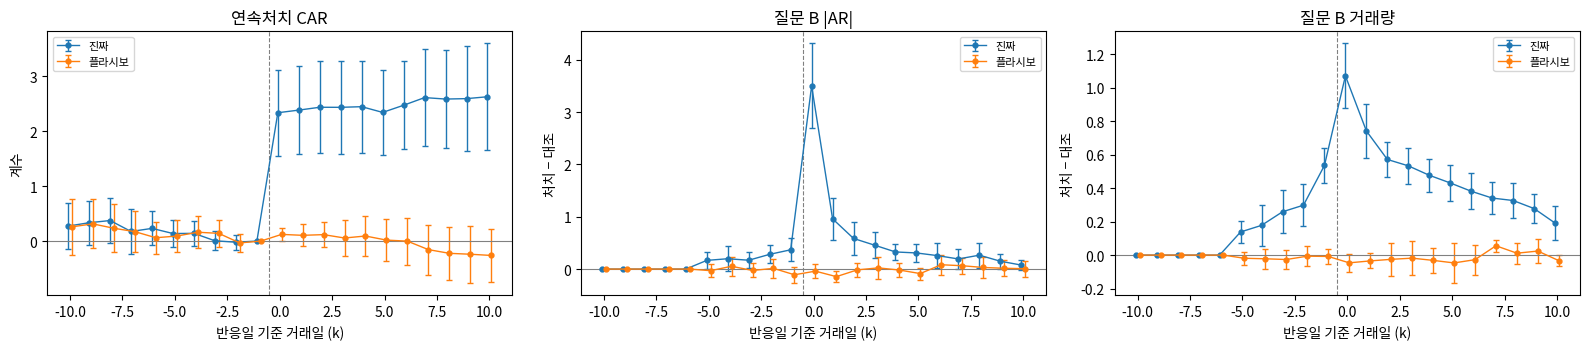

플라시보 연속 CAR  : |계수| 최대 0.31, CI가 0을 벗어난 계수 1/20개
플라시보 B |AR|  : |계수| 최대 0.14, CI가 0을 벗어난 계수 1/16개
플라시보 B 거래량   : |계수| 최대 0.06, CI가 0을 벗어난 계수 2/16개


In [12]:
PCp = build_panel(cont_rows(EVU, shift=PLACEBO_SHIFT))
PBp = build_panel(qb_rows(EVU, shift=PLACEBO_SHIFT))
Pl_c = es_cont(PCp, "car", "sue_z"); Pl_b = es_did(PBp, "abs_ar", ref=REF_BIN); Pl_v = es_did(PBp, "abvol", ref=REF_BIN)
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
plot_es({"진짜": C_car, "플라시보": Pl_c}, "연속처치 CAR", "계수", ax[0])
plot_es({"진짜": B_abs, "플라시보": Pl_b}, "질문 B |AR|", "처치 − 대조", ax[1])
plot_es({"진짜": B_vol, "플라시보": Pl_v}, "질문 B 거래량", "처치 − 대조", ax[2])
plt.tight_layout(); plt.show()
for nm, t in [("연속 CAR", Pl_c), ("B |AR|", Pl_b), ("B 거래량", Pl_v)]:
    s = t[t.se > 0]
    print(f"플라시보 {nm:8s}: |계수| 최대 {s.b.abs().max():.2f}, CI가 0을 벗어난 계수 {int(((s.lo > 0) | (s.hi < 0)).sum())}/{len(s)}개")

## 9. 하위그룹별 (HTE 출발점)

In [13]:
hte = []
for sg in SUBGROUP:
    P = PC[PC.subgroup == sg]
    t = es_cont(P, "car", "sue_z", fe="eid + k")
    d = {"하위그룹": sg, "이벤트": P.eid.nunique()}; d.update(pick(t, (0, 1, 5))); hte.append(d)
pd.DataFrame(hte)

,하위그룹,이벤트,k=0,k=1,k=5
0,large_multiline,132,"1.53 [0.91, 2.16]","1.81 [1.17, 2.45]","1.77 [1.15, 2.38]"
1,personal_lines,88,"3.94 [1.21, 6.66]","3.72 [-0.20, 7.63]","3.67 [-0.04, 7.38]"
2,specialty_reins,286,"2.21 [1.02, 3.40]","2.23 [1.07, 3.40]","2.19 [1.04, 3.35]"


## 10. 결과 요약표 & 저장

In [14]:
def row(name, t, n, k):
    s = t.set_index("k").loc[k]
    return {"분석": name, "이벤트 수": n, "k": k, "추정치": round(s.b, 2), "95% CI": f"[{s.lo:.2f}, {s.hi:.2f}]",
            "p": round(s.p, 3)}
SUMMARY = pd.DataFrame([
    row("질문 B: 발표 효과 |AR| (%p)", B_abs, nb_ev, 0),
    row("질문 B: 발표 효과 |AR| (%p)", B_abs, nb_ev, 1),
    row("질문 B: 발표 효과 비정상 log 거래량", B_vol, nb_ev, 0),
    row("질문 B: 발표 효과 CAR (%p)", B_ar, nb_ev, 1),
    row("질문 A: 커짐 vs 예상 CAR (%p)", A_up, PA_up[PA_up.treat == 1].sid.nunique(), 1),
    row("질문 A: 작아짐 vs 예상 CAR (%p)", A_dn, PA_dn[PA_dn.treat == 1].sid.nunique(), 1),
    row("연속: sue_z 1SD당 CAR (%p)", C_car, PC.eid.nunique(), 0),
    row("연속: sue_z 1SD당 CAR (%p)", C_car, PC.eid.nunique(), 1),
    row("연속: sue_z 1SD당 CAR (%p)", C_car, PC.eid.nunique(), 5),
    row("연속: |sue_z| 1SD당 log 거래량", C_vol, PC.eid.nunique(), 0),
])
import os
os.makedirs("output", exist_ok=True)
SUMMARY.to_csv("output/insurance_summary.csv", index=False, encoding="utf-8-sig")
ROB.to_csv("output/insurance_robustness.csv", index=False, encoding="utf-8-sig")
ev.drop(columns=["t0i"]).to_csv("output/insurance_events.csv", index=False, encoding="utf-8-sig")
SUMMARY

,분석,이벤트 수,k,추정치,95% CI,p
0,질문 B: 발표 효과 |AR| (%p),296,0,3.50,"[2.69, 4.32]",0.000
1,질문 B: 발표 효과 |AR| (%p),296,1,0.96,"[0.56, 1.36]",0.000
2,질문 B: 발표 효과 비정상 log 거래량,296,0,1.07,"[0.88, 1.26]",0.000
3,질문 B: 발표 효과 CAR (%p),296,1,0.68,"[-0.29, 1.66]",0.161
4,질문 A: 커짐 vs 예상 CAR (%p),128,1,3.44,"[1.98, 4.90]",0.000
5,질문 A: 작아짐 vs 예상 CAR (%p),132,1,-2.85,"[-4.11, -1.60]",0.000
6,연속: sue_z 1SD당 CAR (%p),506,0,2.33,"[1.55, 3.11]",0.000
7,연속: sue_z 1SD당 CAR (%p),506,1,2.38,"[1.59, 3.18]",0.000
8,연속: sue_z 1SD당 CAR (%p),506,5,2.34,"[1.56, 3.12]",0.000
9,연속: |sue_z| 1SD당 log 거래량,506,0,0.10,"[0.04, 0.16]",0.002
